In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [36]:
df = pd.read_csv("../dataset/processed/feature_engineered_house_prices.csv")
df.head()

,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,LOCALITY,PRICE_PER_SQFT,SIZE_CATEGORY,BEDS_PER_BATH,TOTAL_BEDS_BATH
0,House for sale,94601238.0,5,5,5938.49,"Moratuwa, Colombo",Colombo,Moratuwa,15930.183936,Very Large,1.00,10
1,House for sale,46044725.0,3,3,1768.45,"Homagama, Colombo",Colombo,Homagama,26036.769487,Medium,1.00,6
2,House for sale,90985626.0,5,4,5063.38,"Boralesgamuwa, Colombo",Colombo,Boralesgamuwa,17969.345773,Very Large,1.25,9
3,House for sale,28967644.0,3,2,2619.82,"Piliyandala, Colombo",Colombo,Piliyandala,11057.112321,Large,1.50,5
4,Villa for sale,98596073.0,5,5,4914.25,"Boralesgamuwa, Colombo",Colombo,Boralesgamuwa,20063.300198,Very Large,1.00,10


In [37]:
features = [
    "TYPE",
    "BEDS",
    "BATH",
    "PROPERTYSQFT",
    "STATE",
    "LOCALITY"
]

target = "PRICE"

x = df[features]
y = df[target]

In [38]:
# train/ test split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
categorical_features = [
    "TYPE",
    "STATE",
    "LOCALITY"
]

numerical_features = [
    "BEDS",
    "BATH",
    "PROPERTYSQFT"
]

In [40]:
# pre-processing pipeline

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=5
            )
        )
    ]
)

numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_transformer,
            categorical_features
        ),
        (
            "numerical",
            numerical_transformer,
            numerical_features
        )
    ]
)

## Models

In [42]:
linear_model = LinearRegression()

In [43]:
decision_tree = DecisionTreeRegressor(
    random_state=42
)

In [44]:
random_forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [45]:
gradient_boosting = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [46]:
xgboost_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror"
)

In [47]:
# models to dictionary

models = {
    "Linear Regression" : linear_model,
    "Random Forest" : random_forest,
    "Decision Tree" : decision_tree,
    "Gradient Boosting" : gradient_boosting,
    "XGBoost Model" : xgboost_model
}

In [48]:
# train all the models

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(
        x_train,
        y_train
    )

    trained_models[name] = pipeline

    print(f"{name} trained successfully.")

Linear Regression trained successfully.
Random Forest trained successfully.
Decision Tree trained successfully.
Gradient Boosting trained successfully.
XGBoost Model trained successfully.


In [49]:
# predictions
predictions = {}

for name, model in trained_models.items():

    predictions[name] = model.predict(x_test)

In [50]:
# evaluate all the models

results = []

for name, y_pred in predictions.items():

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,2.445556e+07,3.348161e+07,0.811003
1,Random Forest,1.590799e+07,2.886274e+07,0.859552
2,Decision Tree,1.867735e+07,3.640336e+07,0.776579
3,Gradient Boosting,1.954625e+07,2.921664e+07,0.856086
4,XGBoost Model,1.616185e+07,2.858071e+07,0.862283


In [51]:
# sort by R2

results_df.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,RMSE,R2
4,XGBoost Model,1.616185e+07,2.858071e+07,0.862283
1,Random Forest,1.590799e+07,2.886274e+07,0.859552
3,Gradient Boosting,1.954625e+07,2.921664e+07,0.856086
0,Linear Regression,2.445556e+07,3.348161e+07,0.811003
2,Decision Tree,1.867735e+07,3.640336e+07,0.776579


In [53]:
# sort by MAE
results_df.sort_values(
    by="MAE",
    ascending=False
)

,Model,MAE,RMSE,R2
0,Linear Regression,2.445556e+07,3.348161e+07,0.811003
3,Gradient Boosting,1.954625e+07,2.921664e+07,0.856086
2,Decision Tree,1.867735e+07,3.640336e+07,0.776579
4,XGBoost Model,1.616185e+07,2.858071e+07,0.862283
1,Random Forest,1.590799e+07,2.886274e+07,0.859552


In [54]:
# Sort by RMSE
results_df.sort_values(
    by="RMSE",
    ascending=False
)

,Model,MAE,RMSE,R2
2,Decision Tree,1.867735e+07,3.640336e+07,0.776579
0,Linear Regression,2.445556e+07,3.348161e+07,0.811003
3,Gradient Boosting,1.954625e+07,2.921664e+07,0.856086
1,Random Forest,1.590799e+07,2.886274e+07,0.859552
4,XGBoost Model,1.616185e+07,2.858071e+07,0.862283


### Model Comparison

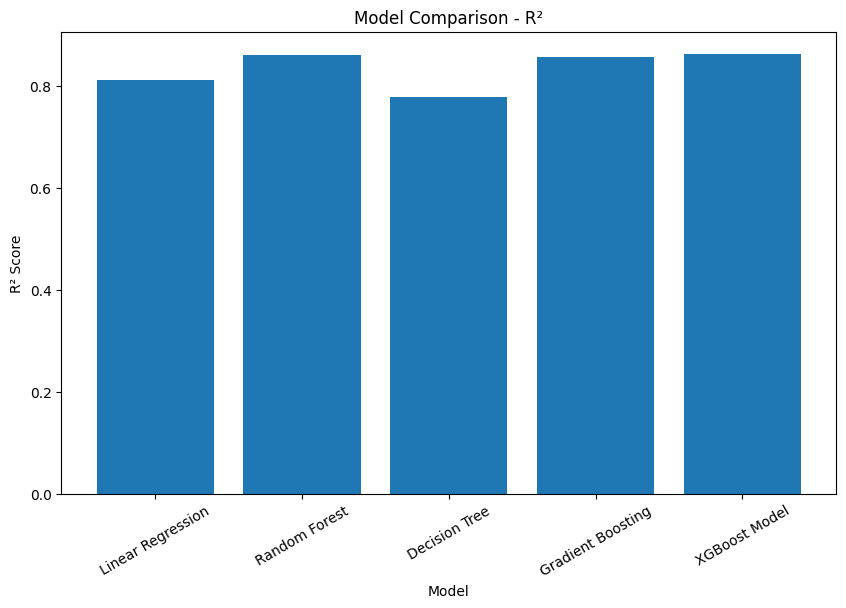

In [55]:
# R2

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["R2"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Comparison - R²")

plt.xticks(rotation=30)

plt.show()

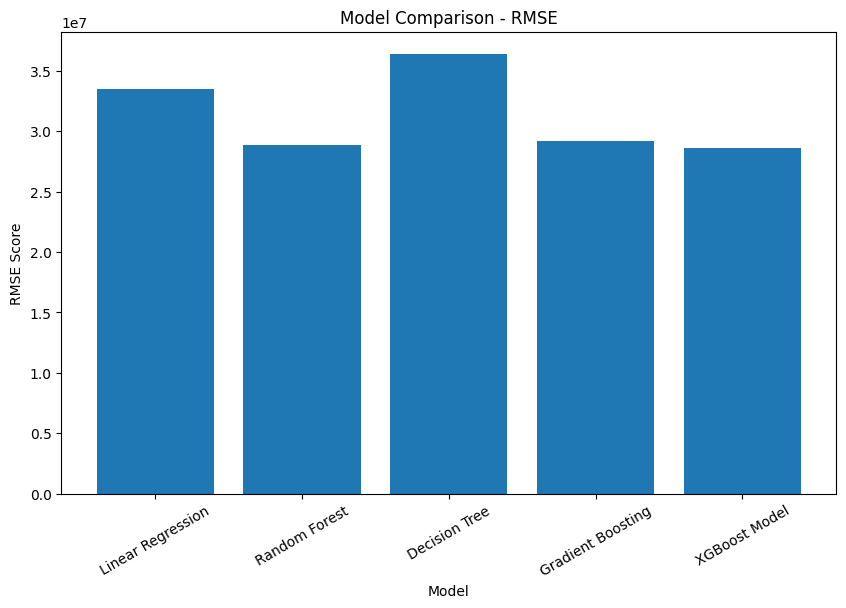

In [56]:
# RMSE

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE Score")
plt.title("Model Comparison - RMSE")

plt.xticks(rotation=30)

plt.show()